# Model Comparison: Subset CheXNet vs Subset Novel Pipeline

This notebook compares the baseline CheXNet (Subset) and the Novel Hybrid Pipeline (Subset) using their saved weights:
1. **Baseline**: `chexnet_subset_best.pth` (DenseNet121)
2. **Novel**: `novel_subset_best.pth` (DenseNet121 + Swin-Transformer + Attention)

## 1. Setup and Imports

In [11]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import timm
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

TARGET_CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]
DATA_DIR = 'data/images'
SUBSET_METADATA_PATH = 'data/metadata_subset_10_percent.csv'

Using device: mps


## 2. Define Architectures

In [12]:
# --- Baseline Model (DenseNet121) ---
def get_baseline_model(path):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, 15)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        print(f"Loaded Baseline weights from {path}")
    else:
        print(f"Warning: {path} not found.")
    return model.to(device).eval()

# --- Novel Hybrid Model (CNN + ViT) ---
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        res = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv(res))

class HybridCheXNet(nn.Module):
    def __init__(self):
        super().__init__()
        cnn = models.densenet121(weights=None)
        self.cnn_features = cnn.features
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)
        self.vit = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0)
        self.spatial_att = SpatialAttention()
        self.classifier = nn.Sequential(nn.Linear(1024 + 768, 512), nn.ReLU())
        self.final_fc = nn.Linear(512, 15)

    def forward(self, x):
        c_feat = self.cnn_features(x)
        c_feat = self.spatial_att(c_feat)
        c_feat = self.cnn_pool(c_feat).view(x.size(0), -1) 
        v_feat = self.vit(x)
        combined = torch.cat([c_feat, v_feat], dim=1)
        out = self.classifier(combined)
        return self.final_fc(out)

def get_novel_model(path):
    model = HybridCheXNet()
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        print(f"Loaded Novel weights from {path}")
    else:
        print(f"Warning: {path} not found.")
    return model.to(device).eval()

## 3. Dataset and Loaders

In [13]:
class ComparisonDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None, use_clahe=False):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform
        self.use_clahe = use_clahe
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        try:
            img_path = os.path.join(self.root_dir, self.dataframe.iloc[idx]['Image Index'])
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            if self.use_clahe:
                lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
                l, a, b = cv2.split(lab)
                image = cv2.cvtColor(cv2.merge((self.clahe.apply(l), a, b)), cv2.COLOR_LAB2RGB)
            image = Image.fromarray(image)
            label = torch.tensor(self.dataframe.iloc[idx]['label_vec'], dtype=torch.float32)
            if self.transform: image = self.transform(image)
            return image, label
        except:
            return torch.zeros((3, 224, 224)), torch.zeros(15)

df = pd.read_csv(SUBSET_METADATA_PATH)
def encode(l): return [1 if c in str(l).split('|') else 0 for c in TARGET_CLASSES]
df['label_vec'] = df['Finding Labels'].apply(encode)
_, val_df = train_test_split(df, test_size=0.15, random_state=42)

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

baseline_loader = DataLoader(ComparisonDataset(val_df, DATA_DIR, val_transform, use_clahe=False), batch_size=16)
novel_loader = DataLoader(ComparisonDataset(val_df, DATA_DIR, val_transform, use_clahe=True), batch_size=16)

## 4. Evaluation Engine

In [14]:
def get_aucs(model, loader):
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader):
            imgs = imgs.to(device)
            out = torch.sigmoid(model(imgs))
            all_preds.append(out.cpu().numpy())
            all_labels.append(labels.numpy())
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    aucs = []
    for i in range(15):
        try: aucs.append(roc_auc_score(labels[:, i], preds[:, i]))
        except: aucs.append(0.5)
    return aucs

## 5. Main Comparison

In [15]:
print("Evaluating Subset CheXNet Baseline...")
aucs_baseline = get_aucs(get_baseline_model('chexnet_subset_best.pth'), baseline_loader)

print("\nEvaluating Subset Novel Hybrid Model...")
aucs_novel = get_aucs(get_novel_model('novel_subset_best.pth'), novel_loader)

results_df = pd.DataFrame({
    'Class': TARGET_CLASSES,
    'Baseline AUC': aucs_baseline,
    'Novel AUC': aucs_novel
})

results_df['Improvement'] = results_df['Novel AUC'] - results_df['Baseline AUC']
display(results_df.sort_values(by='Improvement', ascending=False))

Evaluating Subset CheXNet Baseline...
Loaded Baseline weights from chexnet_subset_best.pth


  0%|          | 0/52 [00:00<?, ?it/s]


Evaluating Subset Novel Hybrid Model...
Loaded Novel weights from novel_subset_best.pth


  0%|          | 0/52 [00:00<?, ?it/s]

,Class,Baseline AUC,Novel AUC,Improvement
14,Pneumothorax,0.683271,0.749853,0.066582
5,Emphysema,0.743900,0.765814,0.021914
11,Nodule,0.635100,0.654274,0.019174
2,Consolidation,0.737489,0.755012,0.017524
9,Mass,0.663867,0.679327,0.015460
10,No Finding,0.729654,0.741349,0.011695
8,Infiltration,0.700239,0.710464,0.010225
3,Edema,0.849506,0.857231,0.007726
6,Fibrosis,0.738951,0.742462,0.003511
0,Atelectasis,0.746017,0.739214,-0.006803


## 6. Plotting

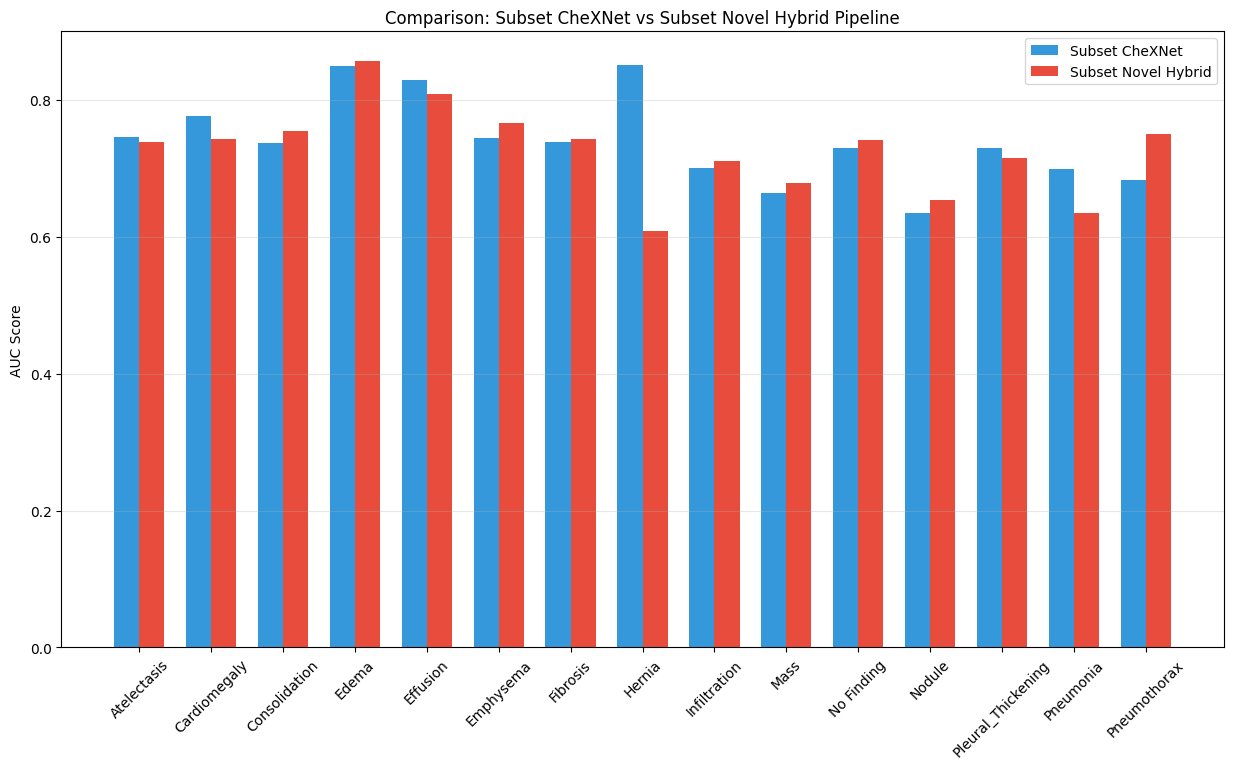

In [16]:
plt.figure(figsize=(15, 8))
x = np.arange(len(TARGET_CLASSES))
width = 0.35

plt.bar(x - width/2, results_df['Baseline AUC'], width, label='Subset CheXNet', color='#3498db')
plt.bar(x + width/2, results_df['Novel AUC'], width, label='Subset Novel Hybrid', color='#e74c3c')

plt.ylabel('AUC Score')
plt.title('Comparison: Subset CheXNet vs Subset Novel Hybrid Pipeline')
plt.xticks(x, TARGET_CLASSES, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()